# Torch Batteries Example: FashionMNIST Diffusion

This notebook trains a class-conditioned diffusion model that generates a requested FashionMNIST category. Diffusers supplies the U-Net, forward noise process, and reverse sampling process; the notebook only adds a small class-conditioning wrapper and the torch-batteries event methods.

## What this notebook demonstrates

- event-driven training, validation, and prediction with `@charge`
- `GradientAccumulation` for a larger effective batch size
- device-aware `MixedPrecision`
- norm-based `GradientClip`
- step-based `LearningRateScheduler`
- lazy generation with `predict_iter()` and safe CPU outputs with `move_to_cpu`

The implementation follows the core DDPM idea: add a known amount of Gaussian noise to an image, train a network to predict that noise, and generate images by repeatedly reversing the process. Conditioning every image on its FashionMNIST label gives the user control over the generated category.

[Callbacks guide](https://michalszc.github.io/torch-batteries/guides/callbacks/) · [Prediction guide](https://michalszc.github.io/torch-batteries/guides/prediction/)

## 0. Prerequisites

Use Python 3.12 or newer. The next cell installs torch-batteries and the `example`
dependencies into the active notebook environment. Restart the kernel if the
notebook application asks you to do so after installation.

Torchvision downloads FashionMNIST (about 30 MB) on the first run. Diffusion is the
most computationally demanding example: it trains on all 60,000 training images for
10 epochs, so CUDA or MPS is strongly recommended and CPU execution can take hours.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup and reproducibility

We seed Python and PyTorch, report the available accelerator, and keep the main runtime settings together. The configuration keeps the referenced conditional design but scales the U-Net to notebook-friendly channels and uses an effective batch size of 128. CUDA or MPS is recommended. For a short CPU walkthrough, reduce `TRAIN_SAMPLES` and `EPOCHS`, with the expectation that generated quality will also decrease.

FashionMNIST is downloaded automatically to `./data` by the data-preparation cell.

In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from diffusers import DDIMScheduler, DDPMScheduler, UNet2DModel
from torch import nn
from torch.nn import functional as nn_functional
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import torch_batteries
from torch_batteries import Battery, Event, EventContext, charge

SEED = 42
BATCH_SIZE = 64
TRAIN_SAMPLES = 60_000
VALIDATION_SAMPLES = 2_000
EPOCHS = 10
TRAIN_TIMESTEPS = 1_000
INFERENCE_STEPS = 100
ACCUMULATION_STEPS = 2
CLASS_NAMES = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
)
DATA_ROOT = Path("./data")

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

accelerator = (
    "CUDA"
    if torch.cuda.is_available()
    else "MPS"
    if torch.backends.mps.is_available()
    else "CPU"
)
print(f"torch-batteries: {torch_batteries.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Available accelerator: {accelerator}")

torch-batteries: 1.0.0
PyTorch: 2.10.0
Available accelerator: MPS


## 2. Download and prepare FashionMNIST

FashionMNIST contains 28×28 grayscale clothing images. `ToTensor` maps pixels to `[0, 1]`; `Normalize` then maps them to `[-1, 1]`, matching the range used by the reverse diffusion process.

The fixed subsets make the notebook reproducible and bounded. Labels are essential here: the denoiser learns which FashionMNIST category it should generate.

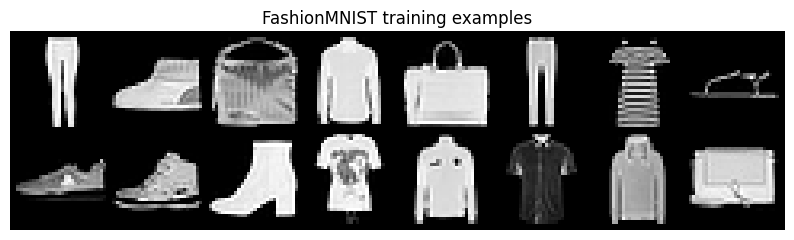

Training samples: 60000 (938 batches)
Validation samples: 2000 (32 batches)


In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)
train_data = datasets.FashionMNIST(
    root=DATA_ROOT, train=True, transform=transform, download=True
)
validation_data = datasets.FashionMNIST(
    root=DATA_ROOT, train=False, transform=transform, download=True
)

subset_generator = torch.Generator().manual_seed(SEED)
train_indices = torch.randperm(len(train_data), generator=subset_generator)[
    :TRAIN_SAMPLES
]
validation_indices = torch.randperm(len(validation_data), generator=subset_generator)[
    :VALIDATION_SAMPLES
]

train_loader = DataLoader(
    Subset(train_data, train_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
validation_loader = DataLoader(
    Subset(validation_data, validation_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

images, labels = next(iter(train_loader))
grid = make_grid((images[:16] + 1) / 2, nrow=8)
plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("FashionMNIST training examples")
plt.show()

print(f"Training samples: {len(train_loader.dataset)} ({len(train_loader)} batches)")
print(
    f"Validation samples: {len(validation_loader.dataset)} "
    f"({len(validation_loader)} batches)"
)

## 3. Diffusion schedule

`DDPMScheduler` owns the complete forward diffusion schedule. The `squaredcos_cap_v2` beta schedule preserves useful signal for much of the process while still reaching an almost completely noisy final state. Its `add_noise` method creates a noisy image at any timestep without manually reproducing scheduler equations.

Generation uses `DDIMScheduler.from_config`, so it shares the training scheduler's beta configuration but can traverse fewer inference steps. Diffusers therefore controls both adding and removing noise.

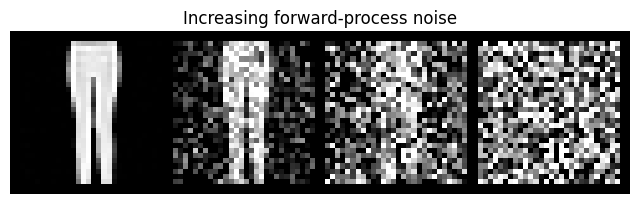

In [3]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=TRAIN_TIMESTEPS,
    beta_schedule="squaredcos_cap_v2",
    clip_sample=True,
)
sampling_scheduler = DDIMScheduler.from_config(noise_scheduler.config)

example_images = images[:1].expand(4, -1, -1, -1)
preview_noise = torch.randn_like(example_images)
preview_steps = torch.tensor(
    [0, TRAIN_TIMESTEPS // 3, 2 * TRAIN_TIMESTEPS // 3, TRAIN_TIMESTEPS - 1]
)
preview_images = noise_scheduler.add_noise(example_images, preview_noise, preview_steps)
preview_grid = make_grid(preview_images.add(1).div(2).clamp(0, 1), nrow=4)
plt.figure(figsize=(8, 2.5))
plt.imshow(preview_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Increasing forward-process noise")
plt.show()

## 4. Define an event-driven denoiser

The network follows the class-conditioned design explored in [AHG_GenAI_FashionMNIST_Conditional_UNet_scratch.ipynb](https://github.com/Huertas97/GenAI-FashionMNIST/blob/main/notebooks/AHG_GenAI_FashionMNIST_Conditional_UNet_scratch.ipynb). Diffusers' native class embedding conditions `UNet2DModel` on the requested label, while its residual and attention blocks handle timestep embeddings, downsampling, and upsampling. The 32/64/128 channel configuration is deliberately smaller than the research-oriented reference model so it remains practical in a notebook.

torch-batteries discovers the decorated model methods:

- `TRAIN_STEP` and `VALIDATION_STEP` return a scalar loss.
- `PREDICT_STEP` runs the complete reverse process for a batch of initial noise.

The wrapper remains focused on domain behavior: preparing conditioned model inputs, calculating diffusion loss, and asking a Diffusers scheduler for each reverse step. Optimization mechanics remain outside the model and are implemented by callbacks.

In [4]:
class ClassConditionedDenoiser(nn.Module):
    def __init__(self, noise_scheduler, sampling_scheduler):
        super().__init__()
        self.noise_scheduler = noise_scheduler
        self.sampling_scheduler = sampling_scheduler
        self.unet = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=(
                "DownBlock2D",
                "AttnDownBlock2D",
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
            ),
            dropout=0.1,
            norm_num_groups=8,
            num_class_embeds=10,
        )

    def forward(self, noisy_images, timesteps, labels):
        return self.unet(noisy_images, timesteps, class_labels=labels).sample

    def diffusion_loss(self, images, labels):
        noise = torch.randn_like(images)
        timesteps = torch.randint(
            0,
            self.noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=images.device,
        )
        noisy_images = self.noise_scheduler.add_noise(images, noise, timesteps)
        predicted_noise = self(noisy_images, timesteps, labels)
        return nn_functional.mse_loss(predicted_noise, noise)

    @charge(Event.TRAIN_STEP)
    def training_step(self, context: EventContext):
        images, labels = context["batch"]
        return self.diffusion_loss(images, labels)

    @charge(Event.VALIDATION_STEP)
    def validation_step(self, context: EventContext):
        images, labels = context["batch"]
        return self.diffusion_loss(images, labels)

    @torch.no_grad()
    def sample(self, initial_noise, labels):
        generated = initial_noise
        self.sampling_scheduler.set_timesteps(INFERENCE_STEPS, device=generated.device)
        for timestep in self.sampling_scheduler.timesteps:
            predicted_noise = self(generated, timestep, labels)
            generated = self.sampling_scheduler.step(
                predicted_noise, timestep, generated
            ).prev_sample
        return {"images": generated.clamp(-1, 1), "labels": labels}

    @charge(Event.PREDICT_STEP)
    def predict_step(self, context: EventContext):
        initial_noise, labels = context["batch"]
        return self.sample(initial_noise, labels)

## 5. Configure optimization callbacks

These callbacks cooperate through public events while their list order remains authoritative:

1. `GradientAccumulation(steps=2)` divides each loss by the actual accumulation-group size, zeros gradients only at group starts, and performs the optimizer operation at group ends. A final partial group is handled automatically.
2. `MixedPrecision("amp")` selects `bf16-mixed` on CPU and `16-mixed` on accelerator devices. It wraps train, validation, and prediction steps in autocast, and uses gradient scaling where fp16 requires it. Use `"32-true"`, `"16-mixed"`, or `"bf16-mixed"` to select a mode explicitly.
3. `GradientClip(1.0, algorithm="norm")` proportionally rescales all gradients only when their combined norm exceeds 1.0. In contrast, `algorithm="value"` independently clamps every gradient element to `[-value, value]`.
4. `LearningRateScheduler(..., interval="step")` advances the reference-style `OneCycleLR` schedule only after a real optimizer step—not after every accumulated batch.

With the default data size, the final training batch forms a partial accumulation group. `GradientAccumulation` still performs that optimizer step and scales its loss by the actual group size. The notebook calculates and verifies the resulting optimizer-step count rather than relying on the number of batches.

The same callbacks support other modes when a workflow needs them:

```python
MixedPrecision("32-true")  # Disable autocast while retaining the event path.
GradientClip(value=0.5, algorithm="value")  # Clamp gradient elements.
LearningRateScheduler(scheduler, interval="epoch")  # Step after each epoch.
```

Only one handler may provide each exclusive optimization operation. For example, two accumulation callbacks would both handle `CONFIGURE_TRAIN_STEP`, so Battery rejects that conflict during event discovery. Models may also attach methods to the same public optimization events when custom behavior is more appropriate than a reusable callback.

In [5]:
from torch_batteries.callbacks import (
    GradientAccumulation,
    GradientClip,
    LearningRateScheduler,
    MixedPrecision,
)

model = ClassConditionedDenoiser(noise_scheduler, sampling_scheduler)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
optimizer_steps_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    total_steps=optimizer_steps_per_epoch * EPOCHS,
)

accumulation = GradientAccumulation(steps=ACCUMULATION_STEPS)
precision = MixedPrecision("amp")
gradient_clip = GradientClip(value=1.0, algorithm="norm")
learning_rate = LearningRateScheduler(scheduler, interval="step")

battery = Battery(
    model,
    device="auto",
    optimizer=optimizer,
    callbacks=[accumulation, precision, gradient_clip, learning_rate],
)

print(f"Battery device: {battery.device}")
print(f"Requested precision: {precision.precision}")
print(f"Effective precision: {precision.effective_precision}")
print(f"Optimizer steps per epoch: {optimizer_steps_per_epoch}")

Battery device: mps
Requested precision: amp
Effective precision: 16-mixed
Optimizer steps per epoch: 469


## 6. Train the noise predictor

`Battery.fit` runs the model's charged steps and broadcasts lifecycle events to the callbacks. The returned `FitResult` contains epoch-level training and validation losses and the actual optimizer-step count, including gradient accumulation. Diffusion loss is noisy by design because each batch receives random timesteps and random noise, so a perfectly monotonic curve is not expected. With the quality-oriented defaults, training can take several minutes on CUDA or MPS and substantially longer on CPU.

Epoch 10/10 [Validation]: 100%|██████████| 32/32 [00:03<00:00, 10.09it/s, Loss=0.0676]


Completed optimizer steps: 4690
Expected optimizer steps: 4690
Final learning rate: 0.000000
Final training loss: 0.0677
Final validation loss: 0.0676


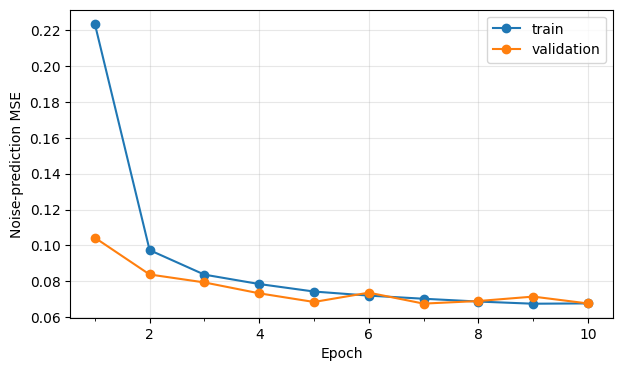

In [6]:
history = battery.fit(
    train_loader,
    validation_loader,
    epochs=EPOCHS,
    verbose=1,
)

expected_optimizer_steps = optimizer_steps_per_epoch * EPOCHS
print(f"Completed optimizer steps: {history['optimizer_steps']}")
print(f"Expected optimizer steps: {expected_optimizer_steps}")
print(f"Final learning rate: {optimizer.param_groups[0]['lr']:.6f}")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")

epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="train")
plt.plot(epochs, history["val_loss"], marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Noise-prediction MSE")
plt.xticks(list(epochs), minor=True)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Stream generated images with `predict_iter()`

Prediction starts from Gaussian noise and requested class labels supplied by a data loader. Diffusers' DDIM scheduler follows a reduced set of inference steps from the training configuration. `predict_iter()` yields one generated batch at a time instead of retaining the entire result. This is useful when generation is large or outputs should be processed immediately.

`move_to_cpu=True` recursively detaches the structured `{"images": ..., "labels": ...}` output and transfers its tensors to CPU before yielding. This prevents generated batches from retaining accelerator memory. Mixed precision also applies here because its execution context wraps all workflow phases, not only training.

When the complete result is small enough to retain, regular prediction can collect it instead: `battery.predict(generation_loader, move_to_cpu=True, concatenate=True)`. Its `"predictions"` value is one concatenated tensor rather than a list of per-batch tensors.

Epoch 1/1 [Predict]: 100%|██████████| 2/2 [00:05<00:00,  2.96s/it]


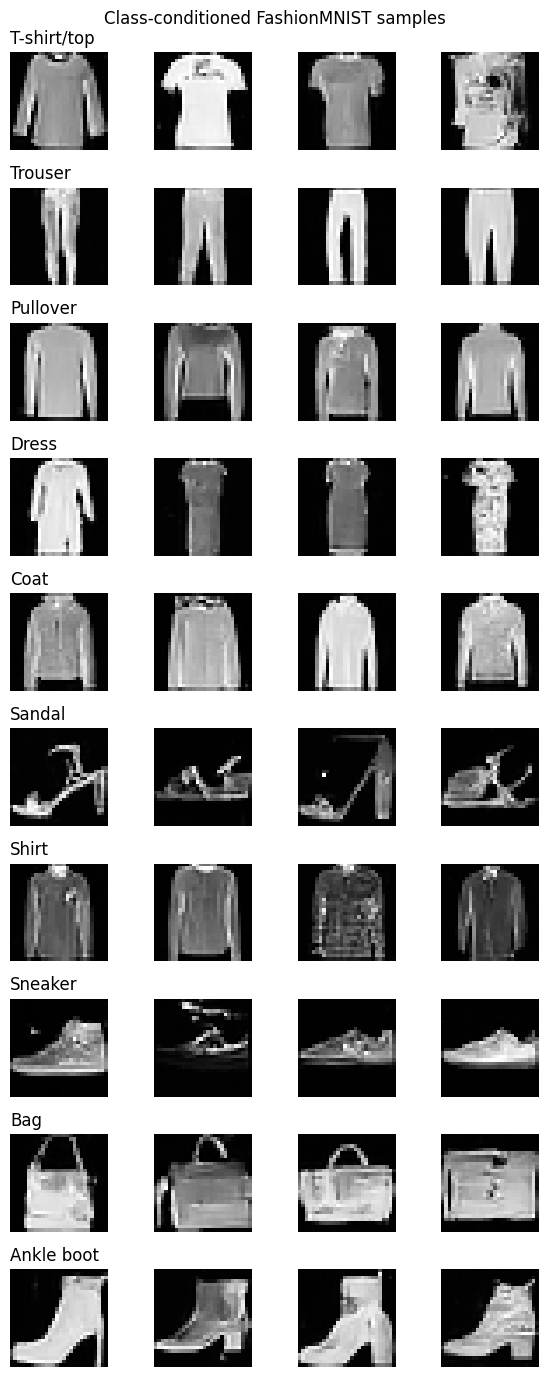

Streamed batches: 2
Generated images: shape=(40, 1, 28, 28), device=cpu; labels=[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 9]


In [7]:
samples_per_class = 4
generation_labels = torch.arange(10).repeat_interleave(samples_per_class)
generation_noise = torch.randn(
    len(generation_labels),
    1,
    28,
    28,
    generator=torch.Generator().manual_seed(7),
)
generation_loader = DataLoader(
    TensorDataset(generation_noise, generation_labels), batch_size=20
)

generated_batches = list(
    battery.predict_iter(generation_loader, verbose=1, move_to_cpu=True)
)
generated_images = torch.cat([batch["images"] for batch in generated_batches])
generated_labels = torch.cat([batch["labels"] for batch in generated_batches])

figure, axes = plt.subplots(10, samples_per_class, figsize=(6, 14))
axes = axes.reshape(10, samples_per_class)
for index, (image, label) in enumerate(
    zip(generated_images, generated_labels, strict=True)
):
    row, column = divmod(index, samples_per_class)
    axes[row, column].imshow(image.squeeze().add(1).div(2), cmap="gray")
    axes[row, column].axis("off")
    if column == 0:
        axes[row, column].set_title(CLASS_NAMES[int(label)], loc="left")
figure.suptitle("Class-conditioned FashionMNIST samples")
figure.tight_layout()
plt.show()

print(f"Streamed batches: {len(generated_batches)}")
print(
    f"Generated images: shape={tuple(generated_images.shape)}, "
    f"device={generated_images.device}; labels={generated_labels.tolist()}"
)